<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 2: Sales Decrease Analysis (2021 vs 2022)</h2>

<p><strong>Scenario:</strong></p>

<p>
The Warehouse Team has observed a surplus in the stock of <strong>"Others"</strong> category products 
at the end of 2022. They want to analyze whether sales declined compared to 2021.
</p>

<p><strong>Objectives:</strong></p>

<ul>
<li>Compare product-level sales between 2021 and 2022</li>
<li>Identify products with the largest decrease in sales</li>
<li>Classify performance as <strong>UP</strong>, <strong>DOWN</strong>, or <strong>FAIR</strong></li>
<li>Visualize the top 20 declining products</li>
</ul>

</div>

In [1]:
import os
import pymysql
import pandas as pd

In [2]:
db_config = {
    "host": "localhost", 
    "user": "root",       
    "password": "baigan",  
    "database": "sales"  
}

In [3]:
output_folder = r"C:\Users\syedm\OneDrive\Desktop\DataNigga" 
os.makedirs(output_folder, exist_ok=True)

In [4]:
queries = {
    
' Analyzing Sales Decrease in the "Others" Category Between 2021 and 2022 Scenario: The Warehouse Team has observed a surplus in the stock of "Others" category products at the end of 2022. They would like to know if sales have declined in 2022 compared to 2021. Additionally, they want to see the 20 products that experienced the largest decrease in sales. Requirements: 1. Create two datasets: o One for sales data in 2021 (qty_ordered for "Others" category). o One for sales data in 2022 (qty_ordered for "Others" category). 2. Merge the datasets and calculate the sales difference between 2022 and 2021. 3. Calculate the percentage change in sales and classify it as "DOWN", "UP", or "FAIR". 4. Sort the products by the largest decrease in sales and show the top 20 products. 5. Create a horizontal bar chart to display the products with the largest decrease in sales between 2022 and 2021. Key Features to Use: • category • order_date (for filtering by year) • is_valid • sku_name • qty_ordered':
    """WITH sales_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sales_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)





SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,

  
    CASE 
        WHEN COALESCE(a.qty_2021, 0) = 0 THEN NULL
        ELSE ((COALESCE(b.qty_2022, 0) - COALESCE(a.qty_2021, 0)) 
              / COALESCE(a.qty_2021, 0)) * 100
    END AS pct_change,

  
    CASE 
        WHEN COALESCE(b.qty_2022, 0) > COALESCE(a.qty_2021, 0) THEN 'UP'
        WHEN COALESCE(b.qty_2022, 0) < COALESCE(a.qty_2021, 0) THEN 'DOWN'
        ELSE 'FAIR'
    END AS trend

FROM sales_2021 a
LEFT JOIN sales_2022 b
    ON a.sku_name = b.sku_name;

"""
}

In [5]:
from IPython.display import display

In [6]:

try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query in queries.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

---  Analyzing Sales Decrease in the "Others" Category Between 2021 and 2022 Scenario: The Warehouse Team has observed a surplus in the stock of "Others" category products at the end of 2022. They would like to know if sales have declined in 2022 compared to 2021. Additionally, they want to see the 20 products that experienced the largest decrease in sales. Requirements: 1. Create two datasets: o One for sales data in 2021 (qty_ordered for "Others" category). o One for sales data in 2022 (qty_ordered for "Others" category). 2. Merge the datasets and calculate the sales difference between 2022 and 2021. 3. Calculate the percentage change in sales and classify it as "DOWN", "UP", or "FAIR". 4. Sort the products by the largest decrease in sales and show the top 20 products. 5. Create a horizontal bar chart to display the products with the largest decrease in sales between 2022 and 2021. Key Features to Use: • category • order_date (for filtering by year) •

C:\Users\syedm\AppData\Local\Temp\ipykernel_26000\1981743706.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,sku_name,qty_2021,qty_2022,pct_change,trend
0,Haier_HSU-18HZE-R2-DB DC Inverter,2.0,0.0,-100.0,DOWN
1,HP_AB201TUN8L18PA,2.0,0.0,-100.0,DOWN
2,Dawlance Split A/C LVS 30 Red 18000BTU LW,2.0,0.0,-100.0,DOWN
3,Careem_50000 Credits,2.0,0.0,-100.0,DOWN
4,Careem_25000 Credits,2.0,0.0,-100.0,DOWN
...,...,...,...,...,...
80,sockoye_QG in Quarter Grey,8.0,0.0,-100.0,DOWN
81,pakistan_Pakistan Car Flag,2.0,0.0,-100.0,DOWN
82,ld_fruit-STRAWBERRY,2.0,0.0,-100.0,DOWN
83,iu_Tickets General Enclosure-Islamabad,40.0,0.0,-100.0,DOWN


Database connection closed.


In [7]:

try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    WITH sales_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sales_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)





SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,

  
    CASE 
        WHEN COALESCE(a.qty_2021, 0) = 0 THEN NULL
        ELSE ((COALESCE(b.qty_2022, 0) - COALESCE(a.qty_2021, 0)) 
              / COALESCE(a.qty_2021, 0)) * 100
    END AS pct_change,

  
    CASE 
        WHEN COALESCE(b.qty_2022, 0) > COALESCE(a.qty_2021, 0) THEN 'UP'
        WHEN COALESCE(b.qty_2022, 0) < COALESCE(a.qty_2021, 0) THEN 'DOWN'
        ELSE 'FAIR'
    END AS trend

FROM sales_2021 a
LEFT JOIN sales_2022 b
    ON a.sku_name = b.sku_name;

    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "pctchange.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\pctchange.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_26000\3292187647.py:65: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [8]:
queries2 = {
    
' Analyzing Sales Decrease in the "Others" Category Between 2021 and 2022 Scenario: The Warehouse Team has observed a surplus in the stock of "Others" category products at the end of 2022. They would like to know if sales have declined in 2022 compared to 2021. Additionally, they want to see the 20 products that experienced the largest decrease in sales. Requirements: 1. Create two datasets: o One for sales data in 2021 (qty_ordered for "Others" category). o One for sales data in 2022 (qty_ordered for "Others" category). 2. Merge the datasets and calculate the sales difference between 2022 and 2021. 3. Calculate the percentage change in sales and classify it as "DOWN", "UP", or "FAIR". 4. Sort the products by the largest decrease in sales and show the top 20 products. 5. Create a horizontal bar chart to display the products with the largest decrease in sales between 2022 and 2021. Key Features to Use: • category • order_date (for filtering by year) • is_valid • sku_name • qty_ordered':
    """WITH sales_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sales_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)



SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) AS decrease
FROM sales_2021 a
LEFT JOIN sales_2022 b
    ON a.sku_name = b.sku_name
WHERE 
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) > 0
ORDER BY decrease DESC
LIMIT 20;
"""
}

In [9]:

try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query1 in queries2.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query1, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

---  Analyzing Sales Decrease in the "Others" Category Between 2021 and 2022 Scenario: The Warehouse Team has observed a surplus in the stock of "Others" category products at the end of 2022. They would like to know if sales have declined in 2022 compared to 2021. Additionally, they want to see the 20 products that experienced the largest decrease in sales. Requirements: 1. Create two datasets: o One for sales data in 2021 (qty_ordered for "Others" category). o One for sales data in 2022 (qty_ordered for "Others" category). 2. Merge the datasets and calculate the sales difference between 2022 and 2021. 3. Calculate the percentage change in sales and classify it as "DOWN", "UP", or "FAIR". 4. Sort the products by the largest decrease in sales and show the top 20 products. 5. Create a horizontal bar chart to display the products with the largest decrease in sales between 2022 and 2021. Key Features to Use: • category • order_date (for filtering by year) •

C:\Users\syedm\AppData\Local\Temp\ipykernel_26000\2061595496.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query1, connection)


,sku_name,qty_2021,qty_2022,decrease
0,RB_Dettol Germ Busting Kit-bf,400.0,80.0,320.0
1,Dawlance_MD 10 + DWB 600,46.0,0.0,46.0
2,Telemall_MM-DR-HB-L,46.0,4.0,42.0
3,iu_Tickets General Enclosure-Islamabad,40.0,0.0,40.0
4,RS_Rehmat-e-Shereen Mix Mithai,26.0,0.0,26.0
5,kansai_NeverWet,20.0,2.0,18.0
6,sindbad_Sindbad Gift Card-3,14.0,0.0,14.0
7,emart_00-1,14.0,2.0,12.0
8,Vouch 365 2016,10.0,0.0,10.0
9,Am-PTV_ATS-004-M,10.0,0.0,10.0


Database connection closed.


In [10]:
try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    WITH sales_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sales_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND skudet.category = 'Others'
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)


SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) AS decrease
FROM sales_2021 a
LEFT JOIN sales_2022 b
    ON a.sku_name = b.sku_name
WHERE 
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) > 0
ORDER BY decrease DESC
LIMIT 20;




    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "top20decrease.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\top20decrease.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_26000\2412794991.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


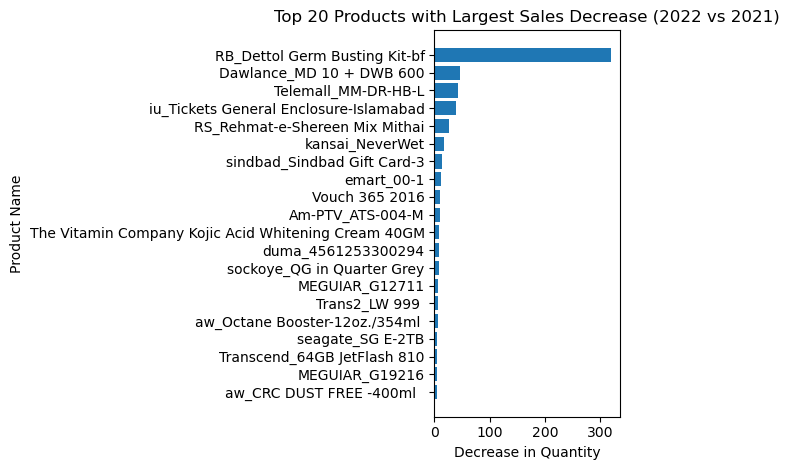

In [11]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="decrease")

plt.figure()

plt.barh(df_sorted["sku_name"], df_sorted["decrease"])

plt.xlabel("Decrease in Quantity")
plt.ylabel("Product Name")
plt.title("Top 20 Products with Largest Sales Decrease (2022 vs 2021)")

plt.tight_layout()